<a href="https://colab.research.google.com/github/SruthiGS-Gito/Case-Study---Assignment-MLAI-B3/blob/main/Case_Study_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

from sklearn.feature_extraction.text import TfidfVectorizer
!pip install gensim
from gensim.models import Word2Vec

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load Data

In [45]:
import kagglehub

path = kagglehub.dataset_download("arunasivapragasam/donors-choose")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'donors-choose' dataset.
Path to dataset files: /kaggle/input/donors-choose


# EDA

In [46]:
file_path = path + "/Preprocessed_DonorsChoose_dataset.csv"
df_donors = pd.read_csv(file_path)
df_donors.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


In [47]:
df_donors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [48]:
df_donors.shape

(109248, 14)

In [49]:
df_donors.describe()

,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,isdigit_summary
count,109248.000000,109248.000000,109248.000000,109248.000000,109248.000000
mean,11.153165,0.848583,298.119343,16.965610,0.144222
std,27.777154,0.358456,367.498030,26.182942,0.351317
min,0.000000,0.000000,0.660000,1.000000,0.000000
25%,0.000000,1.000000,104.310000,4.000000,0.000000
50%,2.000000,1.000000,206.220000,9.000000,0.000000
75%,9.000000,1.000000,379.000000,21.000000,0.000000
max,451.000000,1.000000,9999.000000,930.000000,1.000000


In [50]:
df_donors.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


# Handling missing values

In [51]:
df_donors["cleaned_titles"] = df_donors["cleaned_titles"].fillna("")

### Target : project_is_approved

In [52]:
df_donors["project_is_approved"].value_counts()

,count
project_is_approved,
1,92706
0,16542


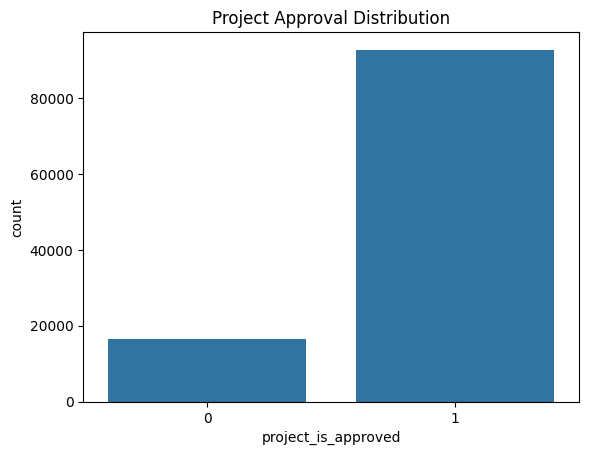

In [53]:
sns.countplot(x="project_is_approved", data=df_donors)
plt.title("Project Approval Distribution")
plt.show()

In [54]:
df_donors["teacher_prefix"].value_counts()

,count
teacher_prefix,
mrs,57272
ms,38955
mr,10648
teacher,2360
dr,13


In [55]:
text_column = "cleaned_essays"

# Preprocessing

In [56]:
# Instead of building three different TF-IDF or Word2Vec
df_donors["combined_text"] = (df_donors["cleaned_titles"] + " " + df_donors["cleaned_summary"] + " " + df_donors["cleaned_essays"])
df_donors["combined_text"].head()

,combined_text
0,educational support english learners home stud...
1,wanted projector hungry learners students_need...
2,soccer equipment awesome middle school student...
3,techie kindergarteners students_need_engage_re...
4,interactive math tools students_need_hands_pra...


## Punctuation Removal

In [57]:
def remove_punctuation(text):
    return "".join(char for char in text if char not in string.punctuation)
df_donors["punctuation_removed"] = df_donors["combined_text"].apply(remove_punctuation)
df_donors[["combined_text", "punctuation_removed"]].head()

,combined_text,punctuation_removed
0,educational support english learners home stud...,educational support english learners home stud...
1,wanted projector hungry learners students_need...,wanted projector hungry learners studentsneedp...
2,soccer equipment awesome middle school student...,soccer equipment awesome middle school student...
3,techie kindergarteners students_need_engage_re...,techie kindergarteners studentsneedengagereadi...
4,interactive math tools students_need_hands_pra...,interactive math tools studentsneedhandspracti...


## Lowercase

In [58]:
df_donors["tokens"] = df_donors["punctuation_removed"].apply(lambda x: word_tokenize(x.lower()))
df_donors["tokens"].head()

,tokens
0,"[educational, support, english, learners, home..."
1,"[wanted, projector, hungry, learners, students..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergarteners, studentsneedengagere..."
4,"[interactive, math, tools, studentsneedhandspr..."


## Lemmatization

In [59]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [60]:
df_donors["lemmatized_tokens"] = df_donors["tokens"].apply(lemmatize_words)
df_donors["lemmatized_tokens"].head()

,lemmatized_tokens
0,"[educational, support, english, learner, home,..."
1,"[wanted, projector, hungry, learner, studentsn..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergartener, studentsneedengagerea..."
4,"[interactive, math, tool, studentsneedhandspra..."


In [74]:
df_donors["lemmatized_tokens"] = df_donors["lemmatized_tokens"].apply(lambda tokens: [word for word in tokens if not re.search(r"\d", word)])

In [75]:
df_donors["lemmatized_tokens"].head()

,lemmatized_tokens
0,"[educational, support, english, learner, home,..."
1,"[wanted, projector, hungry, learner, studentsn..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergartener, studentsneedengagerea..."
4,"[interactive, math, tool, studentsneedhandspra..."


# TF-IDF

### Embedding

In [76]:
df_donors["final_text"] = df_donors["lemmatized_tokens"].apply(" ".join)    # # Joined tokens back into sentences
df_donors["final_text"].head()
df_donors["final_text"].head()

,final_text
0,educational support english learner home stude...
1,wanted projector hungry learner studentsneedpr...
2,soccer equipment awesome middle school student...
3,techie kindergartener studentsneedengagereadin...
4,interactive math tool studentsneedhandspractic...


In [77]:
# 1-gram
tfidf_uni = TfidfVectorizer(ngram_range=(1,1),max_features=50000)
X_tfidf_uni = tfidf_uni.fit_transform(df_donors["final_text"])
X_tfidf_uni.shape

(109248, 50000)

In [78]:
print("Total unigram features:", len(tfidf_uni.get_feature_names_out()))
tfidf_uni.get_feature_names_out()[:20]

Total unigram features: 50000


array(['aa', 'aaa', 'aaagh', 'aaahs', 'aaamath', 'aab', 'aac', 'aae',
       'aafai', 'aagain', 'aahhhhh', 'aahhs', 'aam', 'aaopcs', 'aap',
       'aappl', 'aardvark', 'aargh', 'aaron', 'aarows'], dtype=object)

In [79]:
# 2-gram
tfidf_bi = TfidfVectorizer(ngram_range=(2,2),max_features=50000)
X_tfidf_bi = tfidf_bi.fit_transform(df_donors["final_text"])
X_tfidf_bi.shape

(109248, 50000)

In [80]:
print("Total bigram features:", len(tfidf_bi.get_feature_names_out()))
tfidf_bi.get_feature_names_out()[:20]

Total bigram features: 50000


array(['abc mouse', 'abdominal muscle', 'ability able', 'ability access',
       'ability achieve', 'ability allow', 'ability also',
       'ability attend', 'ability background', 'ability become',
       'ability bring', 'ability build', 'ability building',
       'ability challenge', 'ability change', 'ability child',
       'ability choose', 'ability class', 'ability classroom',
       'ability climb'], dtype=object)

In [81]:
# 3-gram
tfidf_tri = TfidfVectorizer(ngram_range=(3,3),max_features=50000)
X_tfidf_tri = tfidf_tri.fit_transform(df_donors["final_text"])
X_tfidf_tri.shape

(109248, 50000)

In [82]:
print("Total trigram features:", len(tfidf_tri.get_feature_names_out()))
tfidf_tri.get_feature_names_out()[:20]

Total trigram features: 50000


array(['ability autism add', 'ability building drawing',
       'ability classroom student', 'ability climb tree',
       'ability come school', 'ability communicate effectively',
       'ability design create', 'ability english language',
       'ability focus learn', 'ability focus learning',
       'ability gifted special', 'ability help student',
       'ability interest challenge', 'ability learn grow',
       'ability learn new', 'ability learn student',
       'ability learning style', 'ability level background',
       'ability level classroom', 'ability level come'], dtype=object)

# Word2Vec

In [83]:
sentences = df_donors["lemmatized_tokens"].tolist()
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [84]:
len(word2vec_model.wv)

31871

In [85]:
word2vec_model.wv.most_similar("student", topn=5)

[('child', 0.7226899862289429),
 ('kid', 0.6270199418067932),
 ('kiddos', 0.5733733773231506),
 ('classroom', 0.5478355884552002),
 ('class', 0.5402613282203674)]

In [86]:
df_donors["final_text"].head(10)

,final_text
0,educational support english learner home stude...
1,wanted projector hungry learner studentsneedpr...
2,soccer equipment awesome middle school student...
3,techie kindergartener studentsneedengagereadin...
4,interactive math tool studentsneedhandspractic...
5,flexible seating mr jarvis terrific third grad...
6,chromebooks special education reading program ...
7,century studentsneedipadshelpaccessworldonline...
8,targeting success class studentsneedthreedevic...
9,love reading pure pleasure studentsneedgreatbo...


# Model Building

# Evaluation